In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [67]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['q_ps']] will make the shape (#,#) but y = df['q_ps'] will make the shape (#,)

In [68]:
x = df.drop(columns=['q_ihfc','q_ps','q_stein', 'stein_z'])
y = df['q_ps']

In [69]:
x.head()

,lat,long,age,ps_z
0,48.7500,-127.75,2.906279,3096.673436
1,47.8983,-127.20,4.359262,3230.759601
2,47.8983,-127.65,3.190760,3125.194460
3,48.6833,-126.87,5.543758,3324.081515
4,48.6850,-126.87,5.543758,3324.081515


In [70]:
x.shape

(3691, 4)

In [71]:
y.head()

0    277.518538
1    226.597009
2    264.858297
3    200.936360
4    200.936360
Name: q_ps, dtype: float64

In [72]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [73]:
x_train.shape

(2952, 4)

this is the raw validation data

In [74]:
x_test.shape

(739, 4)

In [75]:
x_train.describe().round(3)

,lat,long,age,ps_z
count,2952.000,2952.000,2952.000,2952.000
mean,48.171,-128.319,1.762,2918.034
std,0.323,0.654,1.632,202.893
min,47.686,-129.505,0.009,2533.013
25%,47.883,-128.710,0.592,2769.203
50%,48.291,-128.641,0.912,2834.305
75%,48.455,-127.786,3.251,3131.081
max,48.997,-126.223,6.688,3405.155


In [76]:
x_test.describe().round(3)

,lat,long,age,ps_z
count,739.000,739.000,739.000,739.000
mean,48.169,-128.304,1.793,2919.964
std,0.321,0.675,1.676,208.227
min,47.686,-129.467,0.009,2533.013
25%,47.881,-128.710,0.592,2769.203
50%,48.258,-128.638,0.912,2834.305
75%,48.454,-127.785,3.251,3131.081
max,48.893,-126.223,6.621,3400.602


In [77]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

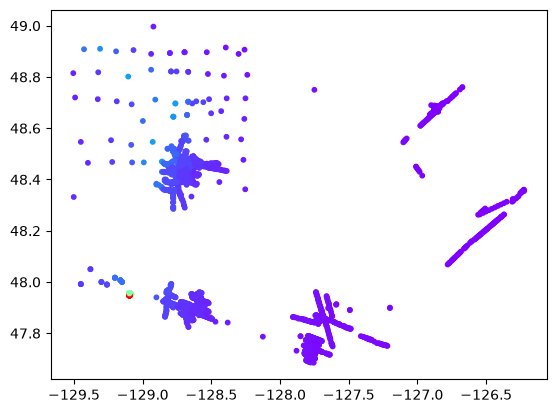

In [78]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

In [79]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':-1
}

In [80]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

In [81]:
y_pred = model.predict(x_test)

In [82]:
y_pred, y_pred.shape

(array([ 262.38263611,  437.88935742,  615.11866861,  615.10515425,
         194.57091059,  531.15668586,  531.18094999,  218.28608096,
         809.35809965,  649.66944154,  262.38263611,  437.80041998,
         262.38263611,  508.5243804 ,  649.42586357,  531.14902937,
        2754.22412732,  614.8806492 ,  615.10458327, 2754.17001483,
         264.84492766,  437.79960485,  262.3776583 ,  262.3776583 ,
         188.73328974,  262.38263611,  615.23754696,  262.38263611,
         200.93263485,  531.18886532,  495.31520606,  201.08981837,
         527.83006655,  884.85979071,  531.15668586,  946.56969042,
         531.1536148 ,  531.1536148 ,  615.10515425,  615.06572637,
         405.66489393,  615.15452468,  705.49150291,  649.55562896,
         249.62709533,  508.33812866,  581.1845925 , 1220.16490536,
         437.79960485,  184.80476316,  615.10458327,  266.13052545,
         262.3776583 ,  262.38263611,  437.79960485,  257.69917476,
         262.38263611,  437.77458048,  531.16220

In [83]:
residuals = y_test - y_pred

negative mean: overpredicting

In [84]:
residuals.head(), residuals.describe()

(3606    0.005156
 652    -0.110016
 1718   -0.014274
 3272   -0.000759
 187     0.056608
 Name: q_ps, dtype: float64,
 count    739.000000
 mean      -0.005495
 std        4.298729
 min      -45.304048
 25%       -0.030832
 50%       -0.000188
 75%        0.008498
 max       98.993099
 Name: q_ps, dtype: float64)

In [85]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'q_ps_test_data': y_test,
    'q_ps_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [86]:
pd.DataFrame(dfr).to_csv('..\\created_data\\seg2_q_ps_residuals.csv', index=False)

with open('..\\created_data\\seg2_q_ps_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

In [87]:
import matplotlib.pyplot as plt

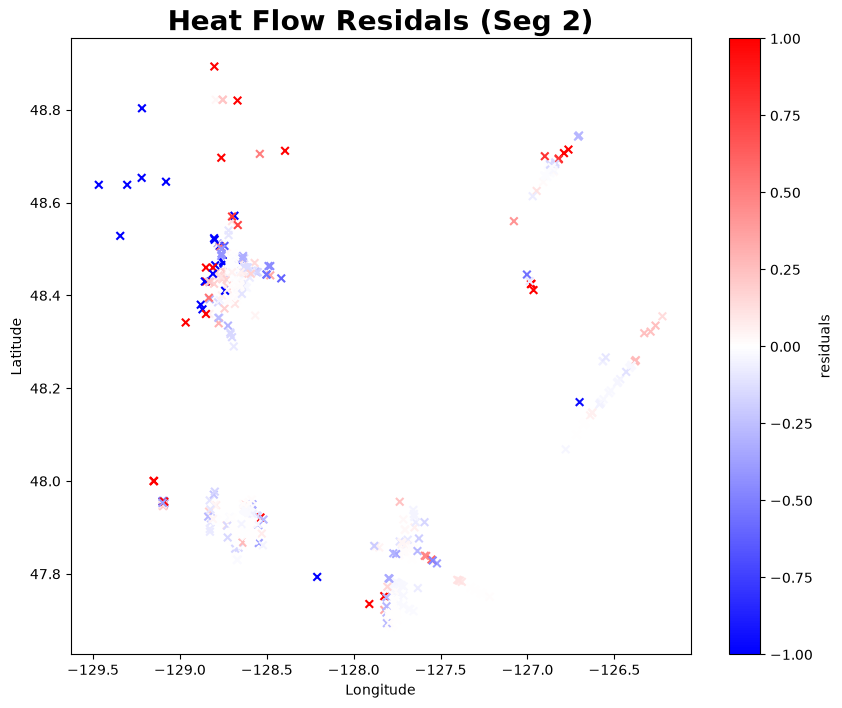

In [88]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='bwr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Heat Flow Residals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\res_q_ps_seg2.png', dpi=400)
plt.show()

In [89]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [90]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [91]:
long.shape, lat.shape

((250, 250), (250, 250))

In [92]:
from scipy.interpolate import griddata

age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
z_interp  = griddata((df['long'], df['lat']), df['ps_z'], (long, lat), method='linear')

In [93]:
age_interp.shape, z_interp.shape

((250, 250), (250, 250))

In [94]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), z_interp.ravel()]).T

In [95]:
lola.shape

(62500, 4)

In [96]:
lola_pred = model.predict(lola)

In [97]:
lola_pred[20:30]

array([5004.84411425, 5004.84411425, 5004.84411425, 5004.84411425,
       5004.84411425, 5004.84411425, 5004.84411425, 5004.84411425,
       5004.84411425, 5004.84411425])

In [98]:
lola_pred = lola_pred.reshape(long.shape)

In [99]:
lola_pred.shape

(250, 250)

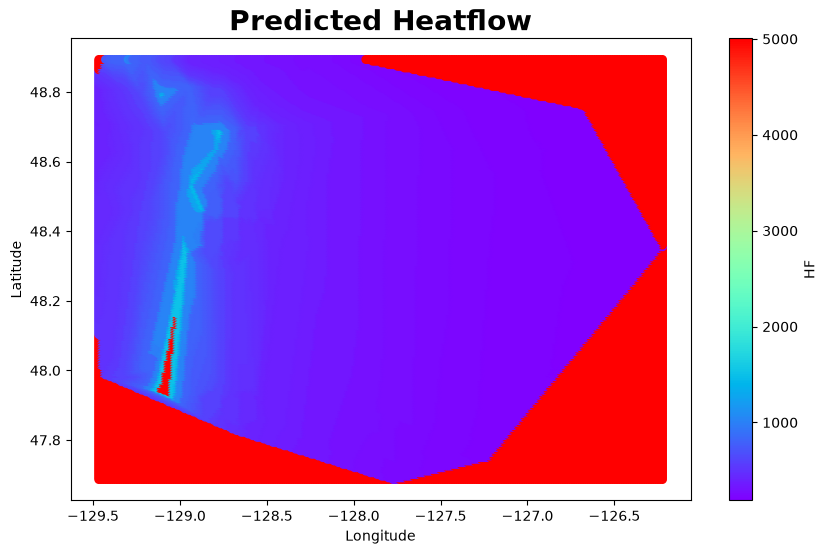

In [100]:
plt.figure(figsize=(10, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='HF')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Heatflow', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig(f'..\\figs\\seg2_q_ps_pred_{sp}.png', dpi=400)
plt.show()

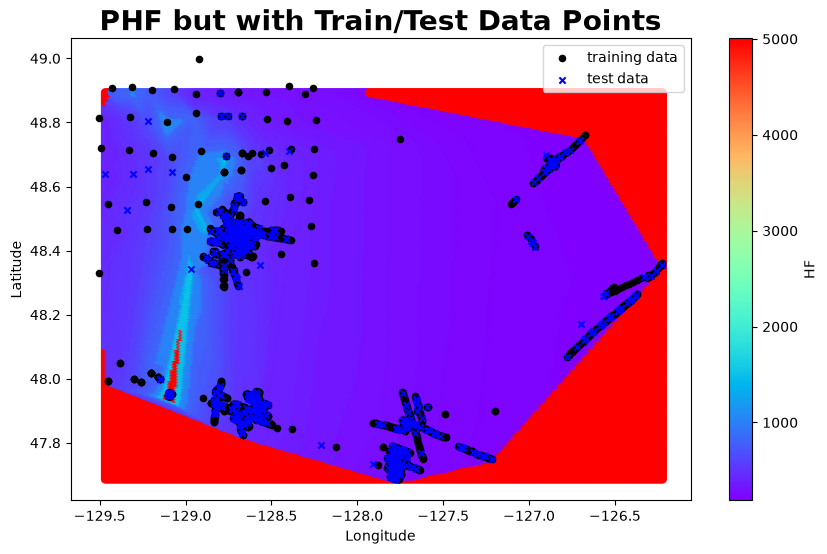

In [101]:
plt.figure(figsize=(10, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='HF')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=20, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=20, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('PHF but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')

plt.savefig(f'..\\figs\\seg2_q_ps_pnts_pred_{sp}.png', dpi=400)
plt.show()